# EPIMETHEUS - Working Example

This notebook demonstrates the complete workflow for building an effective PSF (ePSF) from astronomical images using $\texttt{EPIMETHEUS}$ (Effective Psf Inferred from Mosaics using an Estimation Technique for Heterogeneous Exposures to get a Unique PSF over the Sensor field). See Benotto et al. 2026 for further details

**Overview:**
 1. Define images and load the fits files
 2. Query position angles
 2. Source extraction and star selection
 3. Extract and process star cutouts
 4. Build the ePSF

In [1]:
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
import matplotlib.pyplot as plt
from matplotlib.colors import AsinhNorm
from tqdm import tqdm
import gzip
import os
from astropy.io import fits
import shutil
from astroquery.mast import Observations

import epimetheus as epi

SExtractor found: /usr/bin/source-extractor (Source Extractor version 2.25.0 (2018-02-08))


### Download

The following cell downloads the data used in this example notebook

In [2]:
print("Querying observations. This may take a while...")
obs_table = Observations.query_criteria(provenance_name="canucs")
data_products = Observations.get_product_list(obs_table)
print("Done.")

download_map = {
    "hlsp_canucs_jwst_nircam_macs0416-clu-40mas_f200w_v1_sci.fits.gz": "./f200w_subfield0_sci.fits.gz",
    "hlsp_canucs_jwst_nircam_macs0416-clu-40mas_f200w_v1_rms.fits.gz": "./f200w_subfield0_rms.fits.gz",
    "hlsp_canucs_jwst_nircam_macs0416-ncf-40mas_f200w_v1_sci.fits.gz": "./f200w_subfield1_sci.fits.gz",
    "hlsp_canucs_jwst_nircam_macs0416-ncf-40mas_f200w_v1_rms.fits.gz": "./f200w_subfield1_rms.fits.gz"
}

for product in data_products:
    filename = product['productFilename']
    
    if filename in download_map:
        local_path = download_map[filename]
        print(f"Downloading {filename} as {local_path}...")
        
        Observations.download_file(product['dataURI'], local_path=local_path)
        
        # Unpack to .fits and keep the .gz
        with gzip.open(local_path, 'rb') as f_in, open(local_path.replace('.gz', ''), 'wb') as f_out: shutil.copyfileobj(f_in, f_out)

print("Downloaded and unpacked all files.")

Querying observations. This may take a while...
Done.
INFO: Found cached file ./f200w_subfield0_rms.fits.gz with expected size 93728010. [astroquery.query]
INFO: Found cached file ./f200w_subfield0_rms.fits.gz with expected size 93728010. [astroquery.query]
INFO: Found cached file ./f200w_subfield0_sci.fits.gz with expected size 104514250. [astroquery.query]
INFO: Found cached file ./f200w_subfield0_sci.fits.gz with expected size 104514250. [astroquery.query]
INFO: Found cached file ./f200w_subfield1_rms.fits.gz with expected size 67420259. [astroquery.query]
INFO: Found cached file ./f200w_subfield1_rms.fits.gz with expected size 67420259. [astroquery.query]
INFO: Found cached file ./f200w_subfield1_sci.fits.gz with expected size 79843175. [astroquery.query]
INFO: Found cached file ./f200w_subfield1_sci.fits.gz with expected size 79843175. [astroquery.query]
Downloaded and unpacked all files.


## 1. Define Images and Load the fits files

This section sets up the images (mosaics) information required for ePSF construction. For each image you need to specify:

- **center**: Sky coordinates (RA, DEC) of the field center
- **radius**: Search radius in arcminutes for querying exposures from MAST (to download PA of the single exposures composing the mosaic)
- **data_filepath**: Path to the science image (FITS file)
- **err_filepath**: Path to the error/RMS map (optional but recommended for proper weighting)

You should also set the **filter_name** to match your observations.

**Modify these paths and coordinates to match your data.**

In [3]:
images_info = {
    "M0416": {
        "center": SkyCoord("04:16:13", "-24:05:21", unit=(u.hourangle, u.deg)),
        "radius": 3,  # arcmin
        "data_filepath": "./f200w_subfield0_sci.fits",
        "err_filepath": "./f200w_subfield0_rms.fits"
    },
    "M0416_parall": {
        "center": SkyCoord("04:16:34", "-24:05:39", unit=(u.hourangle, u.deg)),
        "radius": 3,
        "data_filepath": "./f200w_subfield1_sci.fits",
        "err_filepath": "./f200w_subfield1_rms.fits"
    }
}

filter_name = "F200W"

The following cell loads all images into a collection. The code automatically reads key parameters from the FITS headers and compute the others when possible (AB zeropoint, pixel scale, etc.). If a parameter cannot be automatically determined, it can be passed manually to the Image constructor. The `variance_type` parameter specifies how the error map is stored:
- `"rms"` for root-mean-square error maps
- `"var"` for variance maps  
- `"weight"` for inverse-variance weight maps

In [4]:
image_collection = epi.ImagesCollection()

field_names = list(images_info.keys())
for field_name in field_names:
    im = epi.Image(
        image_path=images_info[field_name]["data_filepath"],
        variance_path=images_info[field_name]["err_filepath"],
        variance_type="rms",
        best_PA=None  # Will be determined in the next section
    )
    image_collection.add_image(im, field_name)

print(image_collection)

property      | M0416                    | M0416_parall            
--------------+--------------------------+-------------------------
image path    | f200w_subfield0_sci.fits | f200w_subfield1_sci.fits
AB zeropoint  | 31.40                    | 31.40                   
pixel scale   | 0.04 arcsec              | 0.04 arcsec             
variance type | rms                      | rms                     



Set DATE-END to '2023-01-12T00:26:42.912' from MJD-END'. [astropy.wcs.wcs]
Set DATE-END to '2023-01-12T00:19:10.912' from MJD-END'. [astropy.wcs.wcs]


## 2. Query Position Angles

This section queries the MAST archive through the Grizli https://grizli-cutout.herokuapp.com/ database to retrieve exposure information and determine the most common position angle (PA) for each mosaic. The PA is needed to properly orient the diffraction spikes during ePSF construction.

**Note:** This automatic query only works for HST/JWST data available on MAST. For other observations, you must manually set the PA using `image_collection[field_name].update_best_PA(your_pa_value)`.

**You can modify:**
- `tolerance`: The angular tolerance (in degrees) for grouping exposures with similar PAs. Default is 2°.

In [5]:
for field_name in field_names:
    print(f"Querying: {field_name}")
    
    PAs = epi.GrizliAssociationQuery.query_pa(
        field_name=field_name,
        ra=images_info[field_name]["center"].ra.value,
        dec=images_info[field_name]["center"].dec.value,
        sep=images_info[field_name]["radius"],
        filter_name=filter_name,
        verbose=True,
        is_niriss=False,
        force_recomputation=False,
    )

    if PAs.exposures is not None:
        print(f"Found {len(PAs.exposures)} exposures")

    best_PA = PAs.most_common_angle(tolerance=2.0)
    image_collection[field_name].update_best_PA(best_PA)
    
    print(f"{field_name}: Best PA = {best_PA:.1f}°\n")

Querying: M0416
M0416: Best PA = 310.6°

Querying: M0416_parall
M0416_parall: Best PA = 310.7°



## 3. Source Extraction and Star Selection

This section runs $\texttt{SExtractor}$ to detect sources, then selects point sources (stars) based on aperture flux ratios. Point sources have a characteristic ratio between fluxes measured in narrow and wide apertures, which differs from extended sources.

Define the aperture diameters (in arcseconds) used for the flux ratio calculation.

### Test on the first image

Before processing all images, run the selection on one image to tune the parameters. The diagnostic plot shows the aperture flux ratio vs. magnitude, where stars form a horizontal sequence at a characteristic ratio value.

By default, the first image is used for tuning. Set `force_rerun=True` to re-run SExtractor even if a cached catalogue exists.

Creating clean copy of image


100%|██████████| 42/42 [00:00<00:00, 82.74it/s]


Creating clean copy of rms image


100%|██████████| 42/42 [00:00<00:00, 123.82it/s]


Calling Sextractor
Running SExtractor on ./f200w_subfield0_sci.fits...
  Using weight image: ./f200w_subfield0_rms.fits (MAP_RMS)
Catalogue saved to: ./epi/stars/F200W_M0416.cat
Detected 2495 sources


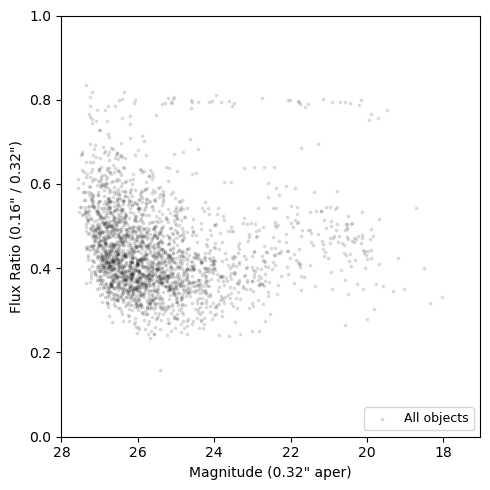

In [6]:
# Aperture diameters in arcsec: (narrow, wide)
APERTURES = np.array((0.16, 0.32))


field_name = field_names[0]

selector = epi.StarSelector(
    image=image_collection[field_name],
    apertures=APERTURES,
    config_overrides={},          # Optional: override SExtractor config parameters
    params_overrides={},          # Optional: override SExtractor output parameters
    star_cat_filename=f"{filter_name}_{field_name}"
)

catalogue = selector.run_sextractor(force_rerun=True)
print(f"Detected {len(catalogue)} sources")

selector.plot_diagnostic(mag_lim=28)

Based on the diagnostic plot above, set the selection parameters:

- **EXPECTED_RATIO**: The aperture flux ratio for point sources (as read from the horizontal sequence in the plot)
- **RATIO_TOLERANCE**: Half-width of the selection band around the expected ratio
- **MAG_LIMIT_MAX**: Faint magnitude limit to avoid noisy sources
- **MAG_LIMIT_MIN**: Bright magnitude limit

**Adjust these values to match the stellar locus in your diagnostic plot.**

Inside this box a k-sigma rejection algorithm will be used to reject possible outliers

Apply the selection criteria and visualize the results. Selected stars are highlighted in the updated diagnostic plot.

Star selection: expected ratio = 0.8000, obtained ratio = 0.7948
Selected 26 stars
Diagnostic plot saved to: ./epi/stars/F200W_M0416_diagnostic.pdf


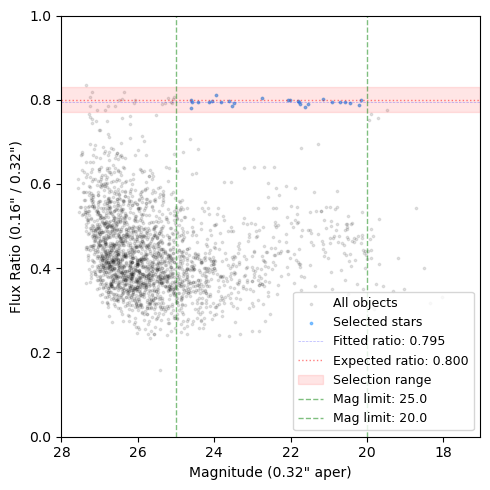

Star catalogue saved to: ./epi/stars/F200W_M0416_stars.cat
Selected 26 stars


In [7]:
EXPECTED_RATIO = 0.80
RATIO_TOLERANCE = 0.03
MAG_LIMIT_MAX = 25.0
MAG_LIMIT_MIN = 20.0

selector.select_stars(
    expected_ratio=EXPECTED_RATIO,
    ratio_tolerance=RATIO_TOLERANCE,
    mag_limit=MAG_LIMIT_MAX,
    mag_bright_limit = MAG_LIMIT_MIN
)

selector.plot_diagnostic(mag_lim=28, show=True, save=True)
selector.save_star_catalogue()

print(f"Selected {len(selector.cat_stars)} stars")

### Process All Images

Apply the tuned selection parameters to all images. The catalogues are saved for later use.

In [8]:
star_catalogues = {}

for field_name in field_names:
    selector = epi.StarSelector(
        image=image_collection.data[field_name],
        apertures=APERTURES,
        config_overrides={},
        params_overrides={},
        star_cat_filename=f"{filter_name}_{field_name}"
    )

    selector.run_sextractor(force_rerun=False)
    selector.select_stars(
        expected_ratio=EXPECTED_RATIO,
        ratio_tolerance=RATIO_TOLERANCE,
        mag_limit=MAG_LIMIT_MAX,
        mag_bright_limit=MAG_LIMIT_MIN,
    )
    selector.plot_diagnostic(mag_lim=28, show=False, save=True)
    selector.save_star_catalogue()

    star_catalogues[field_name] = selector.cat_stars
    print(f"{field_name}: {len(selector.cat_stars)} stars\n")

Loading existing catalogue: ./epi/stars/F200W_M0416.cat
Star selection: expected ratio = 0.8000, obtained ratio = 0.7948
Selected 26 stars
Diagnostic plot saved to: ./epi/stars/F200W_M0416_diagnostic.pdf
Star catalogue saved to: ./epi/stars/F200W_M0416_stars.cat
M0416: 26 stars

Loading existing catalogue: ./epi/stars/F200W_M0416_parall.cat
Star selection: expected ratio = 0.8000, obtained ratio = 0.7962
Selected 14 stars
Diagnostic plot saved to: ./epi/stars/F200W_M0416_parall_diagnostic.pdf
Star catalogue saved to: ./epi/stars/F200W_M0416_parall_stars.cat
M0416_parall: 14 stars



### Merge Catalogues

Combine star catalogues from all images into a single master catalogue. Stars appearing in overlapping regions are deduplicated based on positional matching.

**Parameters:**
- `duplicate_radius`: Maximum separation (in arcseconds) to consider two detections as the same star. Set to `None` to skip deduplication.

In [9]:
DUPLICATE_RADIUS = 0.1  # arcsec

merged_catalogue = epi.MergedCatalogue(
    star_catalogues,
    duplicate_radius=DUPLICATE_RADIUS,
    sort_by_mag=True,
    mag_column="MAG_APER_1"
)

print(f"Total unique stars: {len(merged_catalogue.master_catalog)}")

Building Master Catalog...
  Loaded 26 stars from 1th catalogue
  Loaded 14 stars from 2th catalogue
Total stars before duplicate removal: 40
  Aperture flux ratio: median = 0.7951, std = 0.0057
Unique stars after duplicate removal: 40
Total unique stars: 40


**Alternative: Per-Image ePSF construction**

If you want to build a separate ePSF for each image using only the stars from that image (instead of combining all stars), create individual `MergedCatalogue` objects for each image catalogue and run the remaining steps separately for each one.

In [10]:
# Optional: Create separate catalogues for per-image ePSF construction
per_image_catalogues = []

for field_name in field_names:
    merged = epi.MergedCatalogue(
        {field_name: star_catalogues[field_name]},
        duplicate_radius=None,
        sort_by_mag=True,
        mag_column="MAG_APER_1"
    )
    per_image_catalogues.append(merged)

Building Master Catalog...
  Loaded 26 stars from 1th catalogue
Total stars before duplicate removal: 26
  Aperture flux ratio: median = 0.7947, std = 0.0063
Building Master Catalog...
  Loaded 14 stars from 1th catalogue
Total stars before duplicate removal: 14
  Aperture flux ratio: median = 0.7961, std = 0.0044


## 4. Extract and process star cutouts

This section extracts postage stamp cutouts around each star and processes them for ePSF construction.

Define the ePSF parameters:
- **EPSF_NAME**: Identifier for caching intermediate results
- **FINAL_RESOLUTION**: Pixel scale of the output ePSF (arcsec/pixel)
- **CUTOUT_SHAPE**: Working size of the cutouts (pixels). Should be large enough to capture the full PSF including large regions free from diffraction spikes to compute the background.
- **OUTPUT_SHAPE**: Final ePSF size (pixels). Must be smaller than `CUTOUT_SHAPE/√2` to allow for rotation of cutouts without edge effects



Initialize the `StarCutouts` object, which manages the extraction and processing of all star cutouts.

In [11]:
EPSF_NAME = filter_name

UPSAMPLE_FACTOR = 1

CUTOUT_SHAPE = np.asarray((205, 205))  # Working size (pixels)
OUTPUT_SHAPE = np.asarray((101, 101))  # Final output size (pixels)


cutouts = epi.StarCutouts(
    merged_catalogue,
    image_collection,
    name=EPSF_NAME,
    cutout_shape=CUTOUT_SHAPE,
    upsample_factor=UPSAMPLE_FACTOR,
)

The ePSF will be computed at the ePSF final resolution of 0.04 "/px
Loading cached catalogue: ./epi/epsf_cat/F200W.cat
Loaded 40/40 stars from saved catalogue


### Check Rotation Detection

The code detects the orientation of diffraction spikes using FFT analysis in polar coordinates. This is used to verify that stars have the expected orientation (within tolerance of the nominal PA) and to reject stars with anomalous rotation (e.g., from different exposures with PA different from the most common).

**You should modify these parameters based on your instrument:**
- **ORDER_FFT**: Number of diffraction spikes (6 for JWST, 4 for HST)
- **ANGLE_OF_ONE_SPIKE**: In the angular profile of the cell below, the location of one peak when the PSF is oriented correctly
- **R_MIN, R_MAX**: Inner and outer radii (in arcseconds) defining the annulus where spikes are analyzed

Below some good values for different HST and JWST filters are provided


- **ANGLE_TOLERANCE**: Maximum allowed deviation from the expected rotation (in degrees). Stars with larger deviations are rejected.
- **NORM_APERTURE**: Radius of the circular aperture (in arcseconds) used for flux normalization.

In [12]:
filter_name_lower = filter_name.lower()

HST_FILTERS = {
    'f225w', 'f275w', 'f336w', 'f350lp', 'f435w', 'f475w', 'f606w', 
    'f606wu', 'f625w', 'f775w', 'f814w', 'f814wu', 'f850lp', 'f105w', 
    'f110w', 'f125w', 'f140w', 'f160w'
}

HST_41_DEG_FILTERS = {
    'f225w', 'f275w', 'f336w', 'f350§lp', 'f105w', 'f110w', 'f125w', 
    'f140w', 'f160w'
}

is_hst = filter_name_lower in HST_FILTERS

if filter_name_lower in HST_41_DEG_FILTERS:
    ANGLE_OF_ONE_SPIKE = 41.1
elif is_hst:
    ANGLE_OF_ONE_SPIKE = -2.74
elif filter_name_lower in {"f070w", "f090w"}:
    ANGLE_OF_ONE_SPIKE = 90.0
else:
    ANGLE_OF_ONE_SPIKE = 0.0

if filter_name_lower in {"f140w", "f160w"}:
    R_MIN, R_MAX = 1.0, 2.5
elif filter_name_lower in {"f115w"}:
    R_MIN, R_MAX = 0.15, 0.5
elif filter_name_lower in {"f140m", "f150w", "f162m", "f182m", "f200w", "f210m"}:
    R_MIN, R_MAX = 0.2, 0.8
elif filter_name_lower in {"f250m", "f277w", "f300m", "f335m", "f356w", "f360m", "f410m", "f430m"}:
    R_MIN, R_MAX = 0.3, 1.0
elif filter_name_lower in {"f444w", "f460m", "f480m", "f070w"}:
    R_MIN, R_MAX = 0.4, 1.2
elif filter_name_lower == "f090w" or is_hst:
    R_MIN, R_MAX = 0.6, 2.0
else:
    R_MIN, R_MAX = 0.0, 0.0

ORDER_FFT = 4 if is_hst else 6         # Number of diffraction spikes (6 for JWST, 4 for HST)
ANGLE_TOLERANCE = 4 if is_hst else 2   
NORM_APERTURE = 1.0                    # Normalization aperture radius (arcsec)

print(f"Configured parameters for filter: {filter_name_lower}")

Configured parameters for filter: f200w


### Inspect a Single Star

Before processing all stars, verify that extraction and centering work correctly on a single star. The brightest star (index 0) is used by default since the catalogue is sorted by magnitude.

**You can modify** `star_index` to inspect a different star.

The diagnostic plots show:
1. **Left**: The original PSF with the analysis annulus marked
2. **Right**: The polar transformation of the PSF
3. **Bottom**: The angular profile with detected spike positions

The measured rotation should be close to 0° **if the star matches the expected PA** (As not always the brightest star is oriented as `best_PA`, you can try with another star by changing `star_index` above)

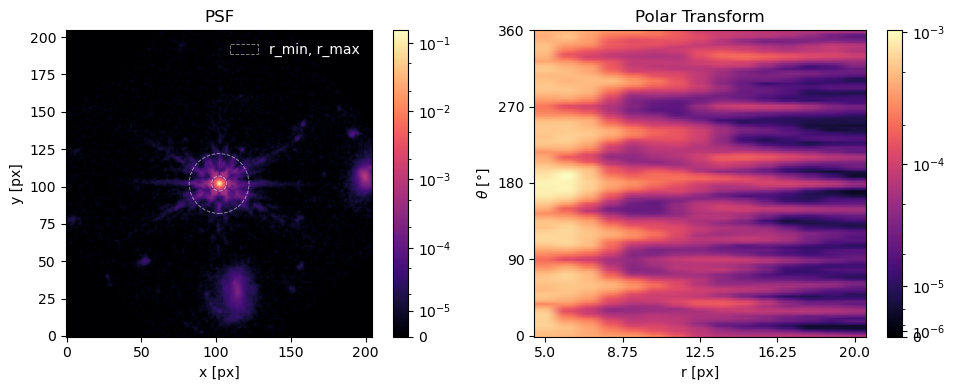

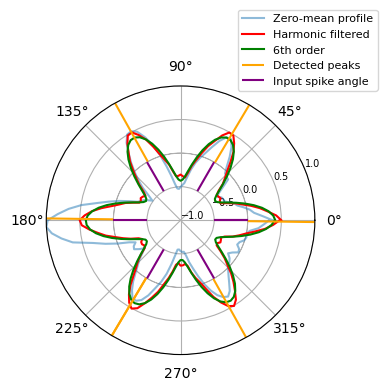

Measured rotation offset: -0.78°


In [13]:
star_index = 0  # Index of the star to inspect (0 = brightest)

cut = cutouts.extract_cutout_ith_star(star_index)
cutouts.subtract_background(star_index)
cutouts.compute_shift_gaussian(star_index)

aligned, _ = cutouts.align_and_rotate_star(star_index, fine_rotation=False, final_angle=0.0, order=1);

rotation = cutouts.compute_rotation(
    star_index,
    order_fft=ORDER_FFT,
    r_min=R_MIN,
    r_max=R_MAX,
    angle_of_one_spike=ANGLE_OF_ONE_SPIKE,
    rotate_first_by_best_pa=True,
    force_recomputation = True,
    ignore_masked_stars = False,
    show=True,
)

print(f"Measured rotation offset: {rotation:.2f}°")

### Process All Stars

Now apply the processing pipeline to all stars using the parameters tuned above.

In [ ]:
cutouts.extract_all_cutouts(force_extraction=False,  extract_invalid_stars=False)
cutouts.subtract_background_all()

cutouts.summary()
cutouts.save_catalogue()

100%|██████████| 40/40 [00:00<00:00, 133.00it/s]

StarCutouts Summary:
  Total stars in catalogue: 40
  Cutouts extracted: 40 (100.0%)
  Valid stars: 0 (0.0%)
  Not yet checked stars: 40 (100.0%)
  Stars with shift computed: 0
  Stars with rotation computed: 0
Catalogue saved: ./epi/epsf_cat/F200W.cat (40 stars)


'./epi/epsf_cat/F200W.cat'

Define the quality control parameters:

The following cell processes each star through the pipeline:
1. Compute centroid shift (Gaussian fit)
2. Measure rotation from diffraction spikes
3. Reject stars with rotation outside tolerance
4. Align and rotate to standard orientation
4. Normalize flux


At the end, save the catalogue with all quality flags.


In [25]:
for star_index in tqdm(range(len(cutouts.stars))):
    star = cutouts.stars[star_index]

    cutouts.compute_shift_gaussian(star_index, force_recomputation=False)

    cutouts.compute_rotation(
        star_index,
        order_fft=ORDER_FFT,
        r_min=R_MIN,
        r_max=R_MAX,
        angle_of_one_spike=ANGLE_OF_ONE_SPIKE,
        rotate_first_by_best_pa=True,
        show=False,
        force_recomputation=False
    )

    cutouts.mask_star_bad_rotation(star_index, ANGLE_TOLERANCE)

    cutouts.align_and_rotate_star(star_index, fine_rotation=False)

    cutouts.normalize_star(star_index, NORM_APERTURE)

print(f"Still valid stars: {len(cutouts.stars) - len(cutouts.get_invalid_stars())}")

cutouts.save_catalogue()

100%|██████████| 40/40 [00:00<00:00, 77.19it/s]

Still valid stars: 33
Catalogue saved: ./epi/epsf_cat/F200W.cat (40 stars)


'./epi/epsf_cat/F200W.cat'

### Visual Review

Manually inspect the processed stars to identify and reject any remaining problematic cases (artifacts, nearby bright sources, cosmic rays, etherogeneous background, ...).

**Interactive controls:**
- **Good**: Accept the star for ePSF construction
- **Bad**: Reject the star
- **Back**: Return to the previous star, to change its state
- **Finish**: End the review session


Stars rejected due to the aperture ratio or rotation angle are not shown here. The manual selection is saved to a file every few steps; therefore, rerunning this cell may yield no results if all stars have already been validated.

In [26]:
reviewer = epi.StarReviewer(cutouts)
reviewer.run()

## 5. Build the ePSF

This section iteratively refines the star positions by fitting each star against the stacked ePSF, then generates the final ePSF at each image most common position angle.

**You can modify:**
- **n_iterations**: Maximum number of refinement iterations
- **rejection_mode**: `'mad'` (median absolute deviation), `'weighted'`, or `'none'`
- **k_sigma**: Sigma threshold for outlier rejection
- **convergence_threshold**: Stop when RMS shift correction falls below this value (pixels)


The convergence plots results figure show:

1. **Top-left**: RMS of shift corrections per iteration (should decrease and stabilize)
2. **Top-right**: Final star centers
3. **Bottom-left**: Scatter plot of shift corrections at each iteration
4. **Bottom-right**: Distribution of shift correction magnitudes

A well-converged solution shows small, randomly distributed corrections centered near zero.

Starting iterative shift refinement
  Valid stars: 11
  Max iterations: 10
  Rejection: mad, k_sigma=3.0
  Recenter ePSF: True
  Convergence threshold: 0.005 px
  Iter 1: rejected 67052 pixel-contribution(s)
  Iter 2: rejected 19077 pixel-contribution(s)
  Initial ePSF recentered by: (-0.0273, -0.0061) px
  Initial FWHM: 1.611 px

--- Iteration 1/10 ---


Fitting shifts: 100%|██████████| 11/11 [00:00<00:00, 228.49it/s]

Updating elaborated cutouts...
  Iter 1: rejected 67938 pixel-contribution(s)
  Iter 2: rejected 19504 pixel-contribution(s)


  ePSF recentered by: (-0.0297, 0.0017) px
  ePSF FWHM: 1.608 px
  RMS correction: 0.0225 px
  Max correction: 0.0403 px
  Mean shift: (-0.0016, -0.2036) px

--- Iteration 2/10 ---


Fitting shifts: 100%|██████████| 11/11 [00:00<00:00, 203.45it/s]

Updating elaborated cutouts...
  Iter 1: rejected 67917 pixel-contribution(s)


  Iter 2: rejected 19514 pixel-contribution(s)
  ePSF recentered by: (-0.0252, -0.0631) px
  ePSF FWHM: 1.659 px
  RMS correction: 0.0029 px
  Max correction: 0.0045 px
  Mean shift: (-0.0036, -0.2067) px

✓ Converged after 2 iterations

Refinement complete: 2 iterations
Converged: True


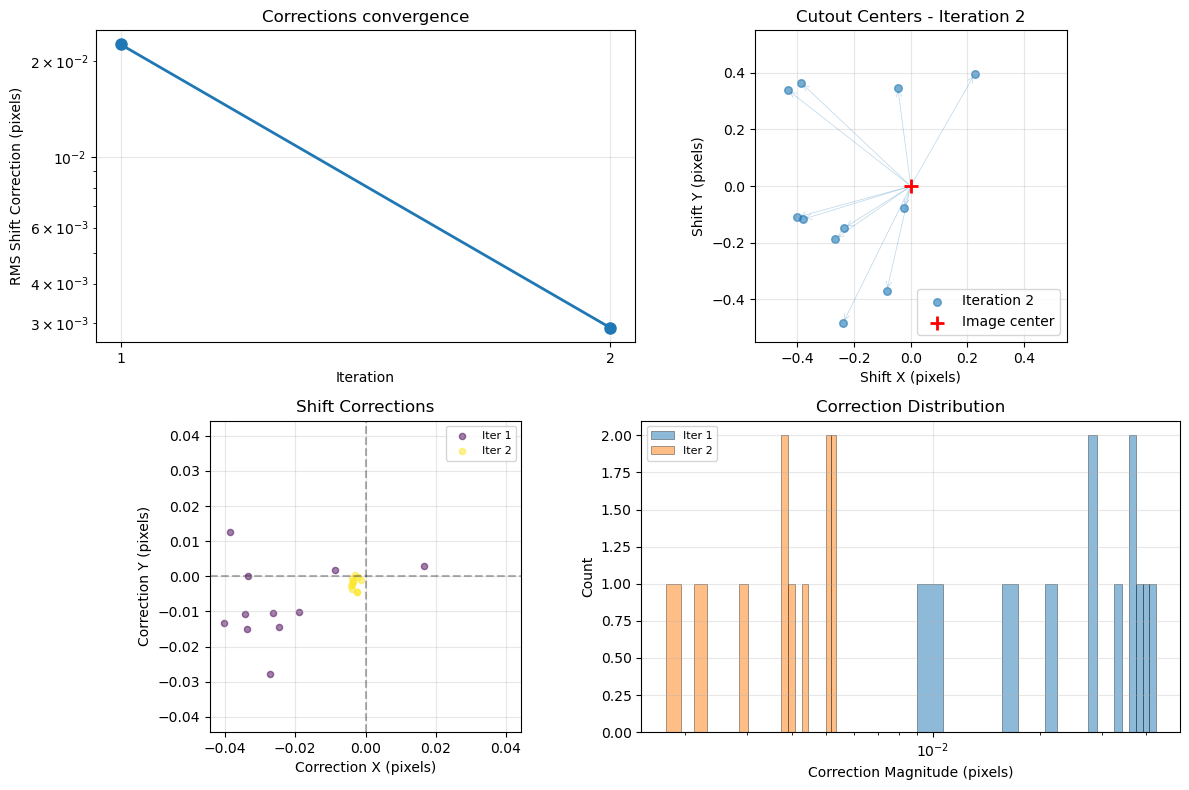

In [28]:
builder = epi.EPIBuilder(cutouts, norm_radius=NORM_APERTURE, pixfrac=0.6)

result = builder.refine_shifts(
    n_iterations=10,
    rejection_mode="mad",
    k_sigma=3.0,
    convergence_threshold=5e-3,
    recenter_epsf=True,
    remove_background=True,
    normalize=True,
    verbose=True
)

builder.plot_convergence_results()


### Generate Final ePSFs

Generate ePSFs for each mosaic using the most common position angle as rotation. The ePSF can be rotated to any desired orientation: here we create one for each mosaic most coomon PA, plus a reference ePSF at PA=0°.

The `angles` dictionary maps output names to position angles (in degrees). You can add any angles you need.

Building ePSFs for angles: {'M0416': np.float64(310.6496244635261), 'M0416_parall': np.float64(310.68104593872897)}
Building multi-angle ePSF
  Angles: ['M0416', 'M0416_parall', 'angle_0']
  Valid stars: 11
  Output shape: (np.int64(101), np.int64(101))

--- M0416 (PA = 310.6496244635261°) ---
  Iter 1: rejected 81889 pixel-contribution(s)
  Iter 2: rejected 23861 pixel-contribution(s)
  FWHM: 1.728 px
  Shape: (101, 101)

--- M0416_parall (PA = 310.68104593872897°) ---
  Iter 1: rejected 81685 pixel-contribution(s)
  Iter 2: rejected 23647 pixel-contribution(s)
  FWHM: 1.728 px
  Shape: (101, 101)

--- angle_0 (PA = 0°) ---
  Iter 1: rejected 67762 pixel-contribution(s)
  Iter 2: rejected 19521 pixel-contribution(s)
  FWHM: 1.583 px
  Shape: (101, 101)

Saved 3 ePSF sets to ./epi/output_psf/


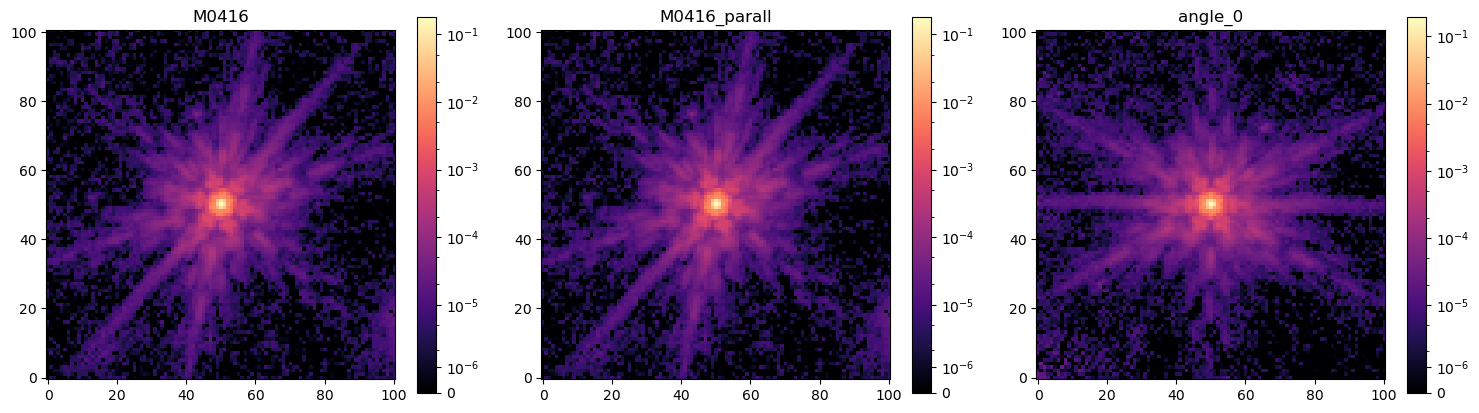


Generated 3 ePSFs


In [29]:
# Build ePSF at each mosaics's position angle
angles = {name: cutouts.image_collection[name].best_PA for name in field_names}

print(f"Building ePSFs for angles: {angles}")

final_epsfs = builder.build_multi_angle_epsf(
    angles=angles,
    output_shape=OUTPUT_SHAPE,
    rejection_mode='mad',
    k_sigma=3.0,
    normalize=True,
    verbose=True,
    show_plots=True,
    save_fits=True
)

#### Display q_fit and sharpness of the ePSF

Extracting the cutout for each star


100%|██████████| 40/40 [00:00<00:00, 332881.27it/s]


FWHM 1.582813115286469
Fitting...


100%|██████████| 40/40 [00:00<00:00, 219.07it/s]


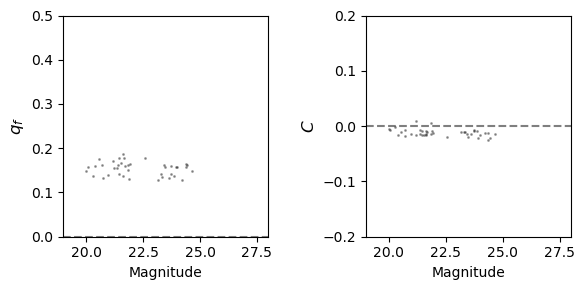

In [30]:
mags, q_fit, sharpness = builder.get_fit_statistics(qFit_region_size = 5)

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(6,3),sharex=True)
ax1.scatter(mags, q_fit, c="k", marker=".", s=5,alpha = 0.3)
ax1.set_ylabel(r"$q_f$",fontsize=12)
ax1.set_xlabel("Magnitude")
ax1.axhline(c="k",alpha=0.5,ls="--")
ax1.set_ylim(0,0.5)
ax1.set_xlim(19,28)

ax2.scatter(mags, sharpness, c="k",marker=".", s=5, alpha=0.3)
ax2.set_ylabel(r"$C$",fontsize=12)
ax2.set_xlabel("Magnitude")
ax2.axhline(c="k",alpha=0.5,ls="--")
ax2.set_ylim(-0.2,0.2)
ax2.set_xlim(19,28)
plt.tight_layout()

plt.show()